# Bug and Corrections notebook 

## Imports 

In [16]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

# PROJECT PATH CONFIGURATION
# INSTRUCTION: Uncomment your specific path below and comment out others.
# This allows to switch between environments 

# user: matteograssini
#ProjectRoot = Path("/Users/matteograssini/Documents/GitHub/intraday-momentum")

# user: giuli 
#ProjectRoot = Path(r"C:\Users\giuli\Repositories\intraday-momentum")

# user: corwin 
ProjectRoot = Path("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/")

src_path = ProjectRoot / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from classes.metrics.metrics import MetricsCalculator
from classes.backtest.engine_new import Momentum
from classes.backtest.default import BacktestDefaults

logging.basicConfig(
level=logging.INFO,
format="%(asctime)s | %(levelname)s | %(message)s",
force=True, # <-- allow printing in jupyter notebooks
)

logger = logging.getLogger(__name__)

In [17]:
spy_path = ProjectRoot / "data/cleaned/SPY_1min_20231027_20251027.pkl"
div_path = ProjectRoot / "data/cleaned/SPY_div_2020-2025.csv"

df_spy = pd.read_pickle(spy_path)
df_spy.drop(columns=["close_deseasonalized"], inplace=True)
df_dividends = pd.read_csv(div_path)

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 194105 entries, 2023-10-30 09:30:00 to 2025-10-27 15:59:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   volume  194105 non-null  float64
 1   open    194105 non-null  float64
 2   high    194105 non-null  float64
 3   low     194105 non-null  float64
 4   close   194105 non-null  float64
dtypes: float64(5)
memory usage: 8.9 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   caldt     20 non-null     object 
 1   dividend  20 non-null     float64
 2   ticker    20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes


### Dividends

In [18]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2025-09-19   1.83111    SPY
1 2025-06-20   1.76112    SPY
2 2025-03-21   1.69553    SPY
3 2024-12-20   1.96555    SPY
4 2024-09-20   1.74553    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [19]:
from classes.metrics.metrics import MetricsCalculator

mc = MetricsCalculator()
mc = MetricsCalculator()
df_spy, df_spy_daily = mc.from_clean_df(df_spy, df_dividends)


2025-12-19 12:35:07,174 | INFO | Starting computation of market microstructure metrics...
2025-12-19 12:35:07,175 | INFO | Computing trading bounds...
2025-12-19 12:35:07,176 | INFO | Computing minute of day...
2025-12-19 12:35:07,262 | INFO | Computing opening prices...
2025-12-19 12:35:07,308 | INFO | Computing price movements...
2025-12-19 12:35:07,312 | INFO | Computing rolling volatility...
2025-12-19 12:35:07,726 | INFO | Computing previous close prices...
2025-12-19 12:35:07,780 | INFO | Computing reference prices...
2025-12-19 12:35:07,930 | INFO | Computing trading bounds...
2025-12-19 12:35:07,937 | INFO | Bounds computation completed.
2025-12-19 12:35:09,291 | INFO | Cleaning dataframe before export...
2025-12-19 12:35:09,408 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-19 12:35:09,411 | INFO | df_daily saved to data/processed/df_daily_groups.pkl


In [20]:
df_spy.head(395)

,Volume,Open,High,Low,Close,Minute_of_day,Sigma_rolling_14d,Upper_bnd,Lower_bnd,Vwap,minute_of_day
Datetime,,,,,,,,,,,
2023-10-30 09:30:00,630285.0,413.560,413.9400,413.530,413.7700,0,NaN,NaN,NaN,413.746667,570
2023-10-30 09:31:00,322290.0,413.780,414.0100,413.750,413.8820,1,NaN,NaN,NaN,413.792004,571
2023-10-30 09:32:00,455364.0,413.910,414.2100,413.845,414.1400,2,NaN,NaN,NaN,413.880298,572
2023-10-30 09:33:00,269190.0,414.130,414.2400,414.050,414.2050,3,NaN,NaN,NaN,413.925994,573
2023-10-30 09:34:00,330914.0,414.205,414.3200,414.205,414.2700,4,NaN,NaN,NaN,413.981860,574
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-31 09:30:00,558005.0,416.180,416.3700,415.760,415.7700,0,0.000746,416.490665,415.269783,415.966667,570
2023-10-31 09:31:00,338641.0,415.770,415.8344,415.600,415.6399,1,0.001038,416.612070,415.148553,415.862718,571
2023-10-31 09:32:00,241075.0,415.640,415.7900,415.590,415.7398,2,0.001230,416.691937,415.068801,415.829638,572


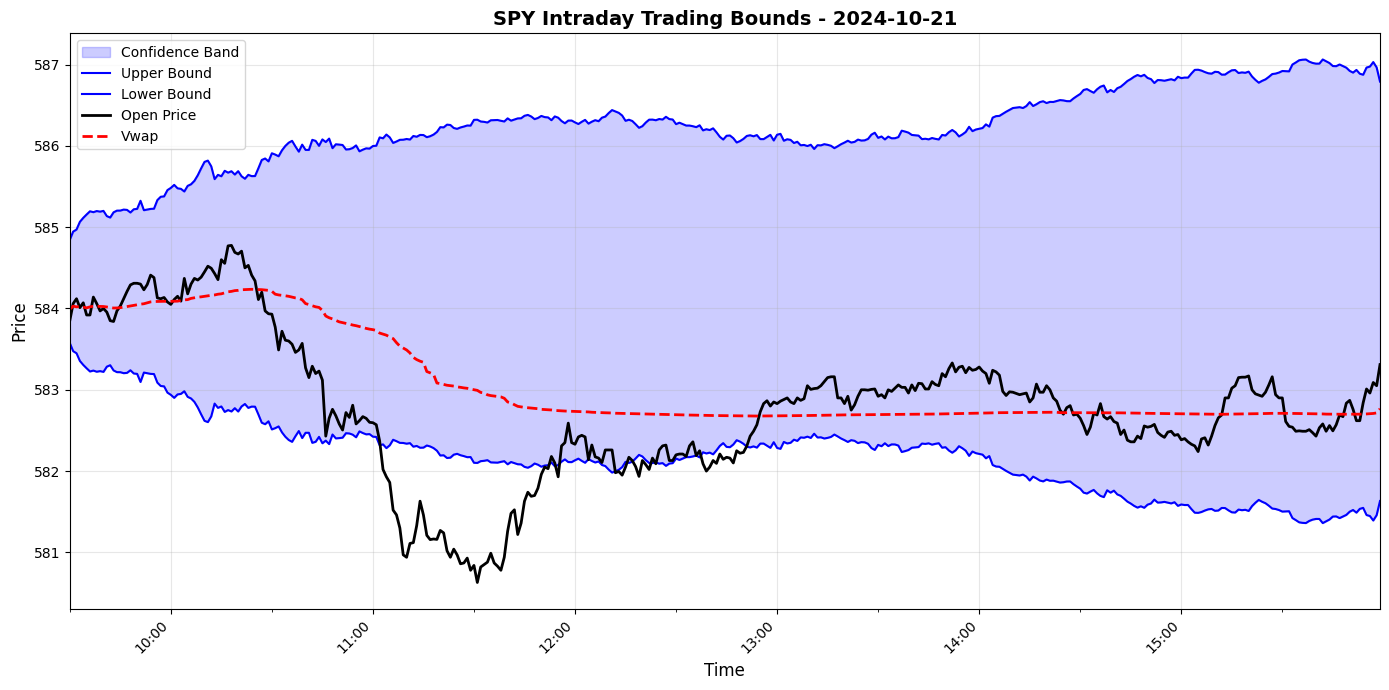

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import pandas as pd
import os


target_date = '2024-10-21'
target_date_dt = pd.to_datetime(target_date)

# Ensure index is datetime
df_spy.index = pd.to_datetime(df_spy.index)

# Filter by the index date
df_day = df_spy[df_spy.index.date == target_date_dt.date()].copy()

if df_day.empty:
    print(f"No intraday data for {target_date}")
    print(f"Available date range: {df_spy.index.min().date()} to {df_spy.index.max().date()}")
else:
    # Set a clean datetime index for matplotlib (use the index which is already datetime)
    if getattr(df_day.index, 'tz', None) is not None:
        try:
            df_day.index = df_day.index.tz_convert(None)
        except Exception:
            try:
                df_day.index = df_day.index.tz_localize(None)
            except Exception:
                pass

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the band with transparency
    ax.fill_between(df_day.index, df_day["Lower_bnd"], df_day["Upper_bnd"], 
                    alpha=0.2, color='blue', label='Confidence Band')

    # Plot Upper and Lower bounds
    ax.plot(df_day.index, df_day["Upper_bnd"], color='blue', linewidth=1.5, label='Upper Bound')
    ax.plot(df_day.index, df_day["Lower_bnd"], color='blue', linewidth=1.5, label='Lower Bound')

    # Plot Open price
    ax.plot(df_day.index, df_day["Open"], color='black', linewidth=2, label='Open Price')

    # Plot Vwap as dashed line if present
    if "Vwap" in df_day.columns:
        ax.plot(df_day.index, df_day["Vwap"], color='red', linewidth=2, label='Vwap', linestyle='--')

    # Create explicit major (hourly) and minor (30min) ticks using pandas date_range
    start = df_day.index[0].floor('h')
    end = df_day.index[-1].ceil('h')
    major_ticks = pd.date_range(start=start, end=end, freq='60min')
    minor_ticks = pd.date_range(start=start, end=end, freq='30min')

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))

    # Tight x-limits and formatting
    ax.set_xlim([df_day.index[0], df_day.index[-1]])
    plt.xticks(rotation=45, ha='right')

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f'SPY Intraday Trading Bounds - {target_date}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

### Backtests

In [ ]:
from classes.backtest.engine_new import Momentum
from backtesting import Backtest

bt = Backtest(
            data =df_spy,
            strategy = Momentum,
            cash = 100_000,
            commission = (0.0035, 0),
            spread = 0.001,
            )

stats = bt.run()
print(stats)
bt.plot()

Start                     2023-10-30 09:30:00
End                       2025-10-27 15:59:00
Duration                    728 days 06:29:00
Exposure Time [%]                    10.20633
Equity Final [$]                  80913.59304
Equity Peak [$]                  100454.22378
Commissions [$]                         1.946
Return [%]                          -19.08641
Buy & Hold Return [%]                65.59441
Return (Ann.) [%]                   -10.12419
Volatility (Ann.) [%]                 3.03079
CAGR [%]                             -7.06633
Sharpe Ratio                         -3.34045
Sortino Ratio                        -4.70396
Calmar Ratio                         -0.49153
Alpha [%]                           -18.22629
Beta                                 -0.01311
Max. Drawdown [%]                   -20.59716
Avg. Drawdown [%]                     -1.4176
Max. Drawdown Duration      713 days 04:45:00
Avg. Drawdown Duration       45 days 09:20:00
# Trades                          

/home/corwyn/Black_swan/Intraday_project/intraday-momentum/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '2h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
